# 10 — Precision Strategy

**Target:** Modal $100 → profit $5-10/hari, stop loss harian $5

**Pendekatan:**
- Sedikit trade tapi presisi tinggi
- Hanya trading di JAM TERBAIK (London + NY open)
- Signal harus dari KONFLUENS KUAT: Trend H1 + S/R Zone + MACD + Candle Pattern
- Daily loss limit: stop setelah -$5
- Daily profit target: stop setelah +$5
- Lot 0.02 (naik dari 0.01 agar target $5/hari tercapai lebih cepat)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

CSV = '../../app/ai/candle_ai/EURUSD.m_M15_202112160545_202603251830.csv'
df_raw = pd.read_csv(CSV, sep='\t')
df_raw.columns = [c.strip('<>').lower() for c in df_raw.columns]
df_raw['datetime'] = pd.to_datetime(df_raw['date'] + ' ' + df_raw['time'])
df_raw = df_raw.set_index('datetime').sort_index()
df_raw = df_raw[['open','high','low','close','tickvol']].rename(columns={'tickvol':'vol'})
print(f'M15: {len(df_raw):,} candles | {df_raw.index[0]} -> {df_raw.index[-1]}')

M15: 100,267 candles | 2021-12-16 05:45:00 -> 2026-03-25 18:30:00


In [2]:
# ── Indikator ──────────────────────────────────────────────────────────────
def ema(s, p): return s.ewm(span=p, adjust=False).mean()
def atr(df, p=14):
    h,l,c = df['high'],df['low'],df['close']
    tr = pd.concat([h-l,(h-c.shift()).abs(),(l-c.shift()).abs()],axis=1).max(axis=1)
    return tr.ewm(span=p,adjust=False).mean()
def macd_hist(s,fast=12,slow=26,sig=9):
    ml = s.ewm(span=fast,adjust=False).mean()-s.ewm(span=slow,adjust=False).mean()
    return ml-ml.ewm(span=sig,adjust=False).mean()

# H1
df_h1 = df_raw.resample('1h').agg({'open':'first','high':'max','low':'min','close':'last'}).dropna()
df_h1['ema50']  = ema(df_h1['close'],50)
df_h1['ema200'] = ema(df_h1['close'],200)
df_h1['atr_h1'] = atr(df_h1,14)
df_h1['slope']  = df_h1['ema50'].diff(3)
df_h1['trend']  = 'sideways'
df_h1.loc[(df_h1['slope']>0)&(df_h1['close']>df_h1['ema200']),'trend'] = 'up'
df_h1.loc[(df_h1['slope']<0)&(df_h1['close']<df_h1['ema200']),'trend'] = 'down'

# M15
df = df_raw.copy()
df['atr']    = atr(df,14)
df['macd_h'] = macd_hist(df['close'])
df['ema9']   = ema(df['close'],9)
df['ema21']  = ema(df['close'],21)
df['trend_h1']  = df_h1['trend'].reindex(df.index,method='ffill')
df['ema50_h1']  = df_h1['ema50'].reindex(df.index,method='ffill')
df['ema200_h1'] = df_h1['ema200'].reindex(df.index,method='ffill')
df['atr_h1']    = df_h1['atr_h1'].reindex(df.index,method='ffill')
print('Indikator selesai')
print(f'H1 trend: {df_h1["trend"].value_counts().to_dict()}')

Indikator selesai
H1 trend: {'down': 10526, 'up': 10351, 'sideways': 5686}


In [3]:
# ── S/R Zone H1 (500 candle lookback) ─────────────────────────────────────
SW_WIN     = 4
H1_LB      = 500
CLUST_DIST = 0.0010
PROX_ATR   = 1.0     # lebih ketat: 1.0x ATR H1

h1_hi  = df_h1['high'].values
h1_lo  = df_h1['low'].values
h1_idx = df_h1.index
nh1    = len(df_h1)

is_sh = np.zeros(nh1,dtype=bool)
is_sl = np.zeros(nh1,dtype=bool)
for i in range(SW_WIN, nh1-SW_WIN):
    if h1_hi[i]==max(h1_hi[i-SW_WIN:i+SW_WIN+1]): is_sh[i]=True
    if h1_lo[i]==min(h1_lo[i-SW_WIN:i+SW_WIN+1]): is_sl[i]=True

def cluster_zones(prices):
    if not prices: return []
    sp = sorted(prices)
    zones,cl = [],[sp[0]]
    for p in sp[1:]:
        if p-cl[-1]<=CLUST_DIST: cl.append(p)
        else: zones.append(np.mean(cl)); cl=[p]
    zones.append(np.mean(cl))
    return zones

nm15     = len(df)
m15_cls  = df['close'].values
m15_ath1 = df['atr_h1'].values
m15_idx  = df.index
h1_idarr = np.array(h1_idx)

in_sup = np.zeros(nm15,dtype=bool)
in_res = np.zeros(nm15,dtype=bool)

prev_h1p = -1
cur_sup,cur_res = [],[]
for i in range(nm15):
    h1p = int(np.searchsorted(h1_idarr, m15_idx[i].floor('1h')))
    if h1p >= nh1: h1p = nh1-1
    if h1p != prev_h1p and h1p >= H1_LB:
        s = h1p-H1_LB
        cur_res = cluster_zones(h1_hi[s:h1p][is_sh[s:h1p]].tolist())
        cur_sup = cluster_zones(h1_lo[s:h1p][is_sl[s:h1p]].tolist())
        prev_h1p = h1p
    c   = m15_cls[i]
    thr = PROX_ATR*(m15_ath1[i] if not np.isnan(m15_ath1[i]) else 0.0012)
    for z in cur_sup:
        if abs(c-z)<=thr: in_sup[i]=True; break
    for z in cur_res:
        if abs(c-z)<=thr: in_res[i]=True; break

df['in_sup'] = in_sup
df['in_res'] = in_res
print(f'In Support Zone   : {in_sup.sum():,} ({in_sup.mean()*100:.1f}%)')
print(f'In Resistance Zone: {in_res.sum():,} ({in_res.mean()*100:.1f}%)')

In Support Zone   : 62,549 (62.4%)
In Resistance Zone: 59,459 (59.3%)


In [4]:
# ── Candle Pattern ─────────────────────────────────────────────────────────
o,h,l,c = df['open'].values,df['high'].values,df['low'].values,df['close'].values
n = len(df)
body = np.abs(c-o)
up_sh = h-np.maximum(o,c)
lo_sh = np.minimum(o,c)-l

# Pin bar
pin_bull = (lo_sh>2.0*body)&(lo_sh>up_sh)&(c>(h+l)/2)
pin_bear = (up_sh>2.0*body)&(up_sh>lo_sh)&(c<(h+l)/2)

# Engulfing
eng_bull = np.zeros(n,dtype=bool)
eng_bear = np.zeros(n,dtype=bool)
for i in range(1,n):
    if c[i]>o[i] and c[i-1]<o[i-1] and c[i]>o[i-1] and o[i]<c[i-1]: eng_bull[i]=True
    if c[i]<o[i] and c[i-1]>o[i-1] and c[i]<o[i-1] and o[i]>c[i-1]: eng_bear[i]=True

df['pat_bull'] = pin_bull | eng_bull
df['pat_bear'] = pin_bear | eng_bear
print(f'Bullish pattern: {(pin_bull|eng_bull).sum():,}')
print(f'Bearish pattern: {(pin_bear|eng_bear).sum():,}')

Bullish pattern: 16,755
Bearish pattern: 16,025


In [5]:
# ── Signal Generation ──────────────────────────────────────────────────────
# JAM TRADING TERBAIK (dari analisis notebook 09):
# London open : 07-12 UTC
# NY open     : 13-18 UTC
# Asia overlap: 01-03 UTC
BEST_HOURS = {1,2,3,7,8,9,10,11,12,13,14,15,16,17,18}

ATR_MIN = 0.0008

trend_arr = df['trend_h1'].values
macd_arr  = df['macd_h'].values
ema9_arr  = df['ema9'].values
ema21_arr = df['ema21'].values
atr_arr   = df['atr'].values
ins_arr   = df['in_sup'].values
inr_arr   = df['in_res'].values
pb_arr    = df['pat_bull'].values
pp_arr    = df['pat_bear'].values

macd_up   = np.zeros(n,dtype=bool)
macd_down = np.zeros(n,dtype=bool)
for i in range(1,n):
    if macd_arr[i]>macd_arr[i-1] and macd_arr[i]>0: macd_up[i]=True
    elif macd_arr[i]<macd_arr[i-1] and macd_arr[i]<0: macd_down[i]=True

sig_arr   = np.full(n,'hold',dtype=object)
score_arr = np.zeros(n,dtype=int)
hour_arr  = np.array([t.hour for t in df.index])

START = H1_LB*4
for i in range(START,n):
    if atr_arr[i]<ATR_MIN: continue
    if hour_arr[i] not in BEST_HOURS: continue  # filter jam

    # BUY
    if trend_arr[i]=='up' and ins_arr[i]:
        sc = 2  # trend + zona
        if macd_up[i]:              sc+=1
        if ema9_arr[i]>ema21_arr[i]: sc+=1
        if pb_arr[i]:               sc+=1  # candle pattern
        if sc>=3:
            sig_arr[i]='buy'; score_arr[i]=sc

    # SELL
    elif trend_arr[i]=='down' and inr_arr[i]:
        sc = 2
        if macd_down[i]:             sc+=1
        if ema9_arr[i]<ema21_arr[i]: sc+=1
        if pp_arr[i]:                sc+=1
        if sc>=3:
            sig_arr[i]='sell'; score_arr[i]=sc

df['signal'] = sig_arr
df['score']  = score_arr

print(pd.Series(sig_arr).value_counts())
print()
print('Score (non-hold):')
print(df[df['signal']!='hold']['score'].value_counts().sort_index())

hold    92158
buy      4164
sell     3945
Name: count, dtype: int64

Score (non-hold):
score
3    4978
4    2737
5     394
Name: count, dtype: int64


In [6]:
# ── Backtest dengan Daily Limit ────────────────────────────────────────────
# Stop trading hari itu kalau:
#   - Profit hari ini >= +$5  (daily target tercapai)
#   - Loss hari ini  <= -$5   (daily stop loss)
# Lot 0.02 (pip value = $0.20/pip)

def run_precision_backtest(df, rr_mult=1.5, min_score=3, max_candle=16,
                            lot=0.02, daily_tp=5.0, daily_sl=-5.0, modal=100.0):
    cls = df['close'].values
    hi  = df['high'].values
    lo  = df['low'].values
    at  = df['atr'].values
    sig = df['signal'].values
    sc  = df['score'].values
    idx = df.index
    n   = len(df)
    pip_val = lot * 10  # EURUSD: 1 pip = $10 per lot

    trades      = []
    equity      = modal
    daily_pnl   = {}  # date -> total pnl hari itu
    daily_stop  = {}  # date -> True jika hari itu sudah stop

    i = 0
    while i < n:
        if sig[i] not in ('buy','sell') or sc[i] < min_score:
            i+=1; continue

        trade_date = idx[i].date()

        # Cek daily limit
        d_pnl = daily_pnl.get(trade_date, 0.0)
        if daily_stop.get(trade_date, False):
            i+=1; continue
        if d_pnl >= daily_tp or d_pnl <= daily_sl:
            daily_stop[trade_date] = True
            i+=1; continue

        d     = sig[i]
        entry = cls[i]
        sl_d  = 1.0*at[i]
        tp_d  = rr_mult*at[i]
        sl    = entry-sl_d if d=='buy' else entry+sl_d
        tp    = entry+tp_d if d=='buy' else entry-tp_d

        outcome='timeout'; ep=entry
        for j in range(i+1, min(i+1+max_candle,n)):
            if d=='buy':
                if lo[j]<=sl: outcome='loss'; ep=sl; break
                if hi[j]>=tp: outcome='win';  ep=tp; break
            else:
                if hi[j]>=sl: outcome='loss'; ep=sl; break
                if lo[j]<=tp: outcome='win';  ep=tp; break

        pips   = (ep-entry)*10000 if d=='buy' else (entry-ep)*10000
        usd    = pips*pip_val
        equity += usd

        daily_pnl[trade_date] = daily_pnl.get(trade_date,0.0) + usd

        trades.append({
            'datetime': idx[i], 'date': trade_date,
            'direction': d, 'score': int(sc[i]),
            'entry': round(entry,5), 'sl': round(sl,5), 'tp': round(tp,5),
            'exit': round(ep,5), 'outcome': outcome,
            'pips': round(pips,1), 'usd': round(usd,2),
            'equity': round(equity,2), 'daily_pnl': round(daily_pnl[trade_date],2)
        })
        i += max_candle+1

    return pd.DataFrame(trades), daily_pnl

trades, daily_pnl = run_precision_backtest(df, rr_mult=1.5, min_score=3,
                                            lot=0.02, daily_tp=5.0, daily_sl=-5.0)
print(f'Total trades: {len(trades)}')
print(f'Trading days: {len(daily_pnl)}')

Total trades: 1152
Trading days: 711


In [7]:
# ── Analisis Hasil ─────────────────────────────────────────────────────────
if len(trades) > 0:
    wins    = (trades['outcome']=='win').sum()
    losses  = (trades['outcome']=='loss').sum()
    timeout = (trades['outcome']=='timeout').sum()
    total   = len(trades)
    wr      = wins/total*100
    aw      = trades.loc[trades['outcome']=='win','pips'].mean()
    al      = trades.loc[trades['outcome']=='loss','pips'].mean()
    tp_sum  = trades['pips'].sum()
    gp      = trades.loc[trades['pips']>0,'pips'].sum()
    gl      = abs(trades.loc[trades['pips']<0,'pips'].sum() or 1)
    pf      = gp/gl
    max_dd  = (trades['equity'].cummax()-trades['equity']).max()

    # Daily stats
    dpnl = pd.Series(daily_pnl)
    days_profit = (dpnl>0).sum()
    days_loss   = (dpnl<0).sum()
    days_flat   = (dpnl==0).sum()
    days_hit_tp = (dpnl>=5).sum()
    days_hit_sl = (dpnl<=-5).sum()
    avg_daily   = dpnl[dpnl!=0].mean()

    print('='*54)
    print('  PRECISION STRATEGY — HASIL BACKTEST')
    print('  Modal $100 | Lot 0.02 | Daily TP $5 / SL -$5')
    print('='*54)
    print(f'  Periode       : Des 2021 - Mar 2026 (~4 tahun)')
    print(f'  Total Trade   : {total}  (~{total//51}/bulan)')
    print(f'  Win/Loss/TO   : {wins}/{losses}/{timeout}')
    print(f'  Win Rate      : {wr:.1f}%')
    print(f'  Avg Win       : +{aw:.1f} pips  (+${aw*0.02*10:.2f})')
    print(f'  Avg Loss      : {al:.1f} pips  (${al*0.02*10:.2f})')
    print(f'  Profit Factor : {pf:.2f}')
    print(f'  Total Pips    : {tp_sum:+.1f}')
    print(f'  Total USD     : ${trades["usd"].sum():+.2f}')
    print(f'  Max Drawdown  : ${max_dd:.2f}')
    print(f'  Equity Akhir  : ${trades["equity"].iloc[-1]:.2f}')
    print()
    print(f'--- DAILY STATS ---')
    print(f'  Hari profit   : {days_profit} hari')
    print(f'  Hari loss     : {days_loss} hari')
    print(f'  Hit target $5+: {days_hit_tp} hari')
    print(f'  Hit stop -$5  : {days_hit_sl} hari')
    print(f'  Avg P&L/hari  : ${avg_daily:.2f}')
    print('='*54)

  PRECISION STRATEGY — HASIL BACKTEST
  Modal $100 | Lot 0.02 | Daily TP $5 / SL -$5
  Periode       : Des 2021 - Mar 2026 (~4 tahun)
  Total Trade   : 1152  (~22/bulan)
  Win/Loss/TO   : 500/569/83
  Win Rate      : 43.4%
  Avg Win       : +16.2 pips  (+$3.24)
  Avg Loss      : -10.9 pips  ($-2.19)
  Profit Factor : 1.30
  Total Pips    : +1872.2
  Total USD     : $+374.54
  Max Drawdown  : $31.82
  Equity Akhir  : $474.53

--- DAILY STATS ---
  Hari profit   : 374 hari
  Hari loss     : 304 hari
  Hit target $5+: 78 hari
  Hit stop -$5  : 35 hari
  Avg P&L/hari  : $0.55


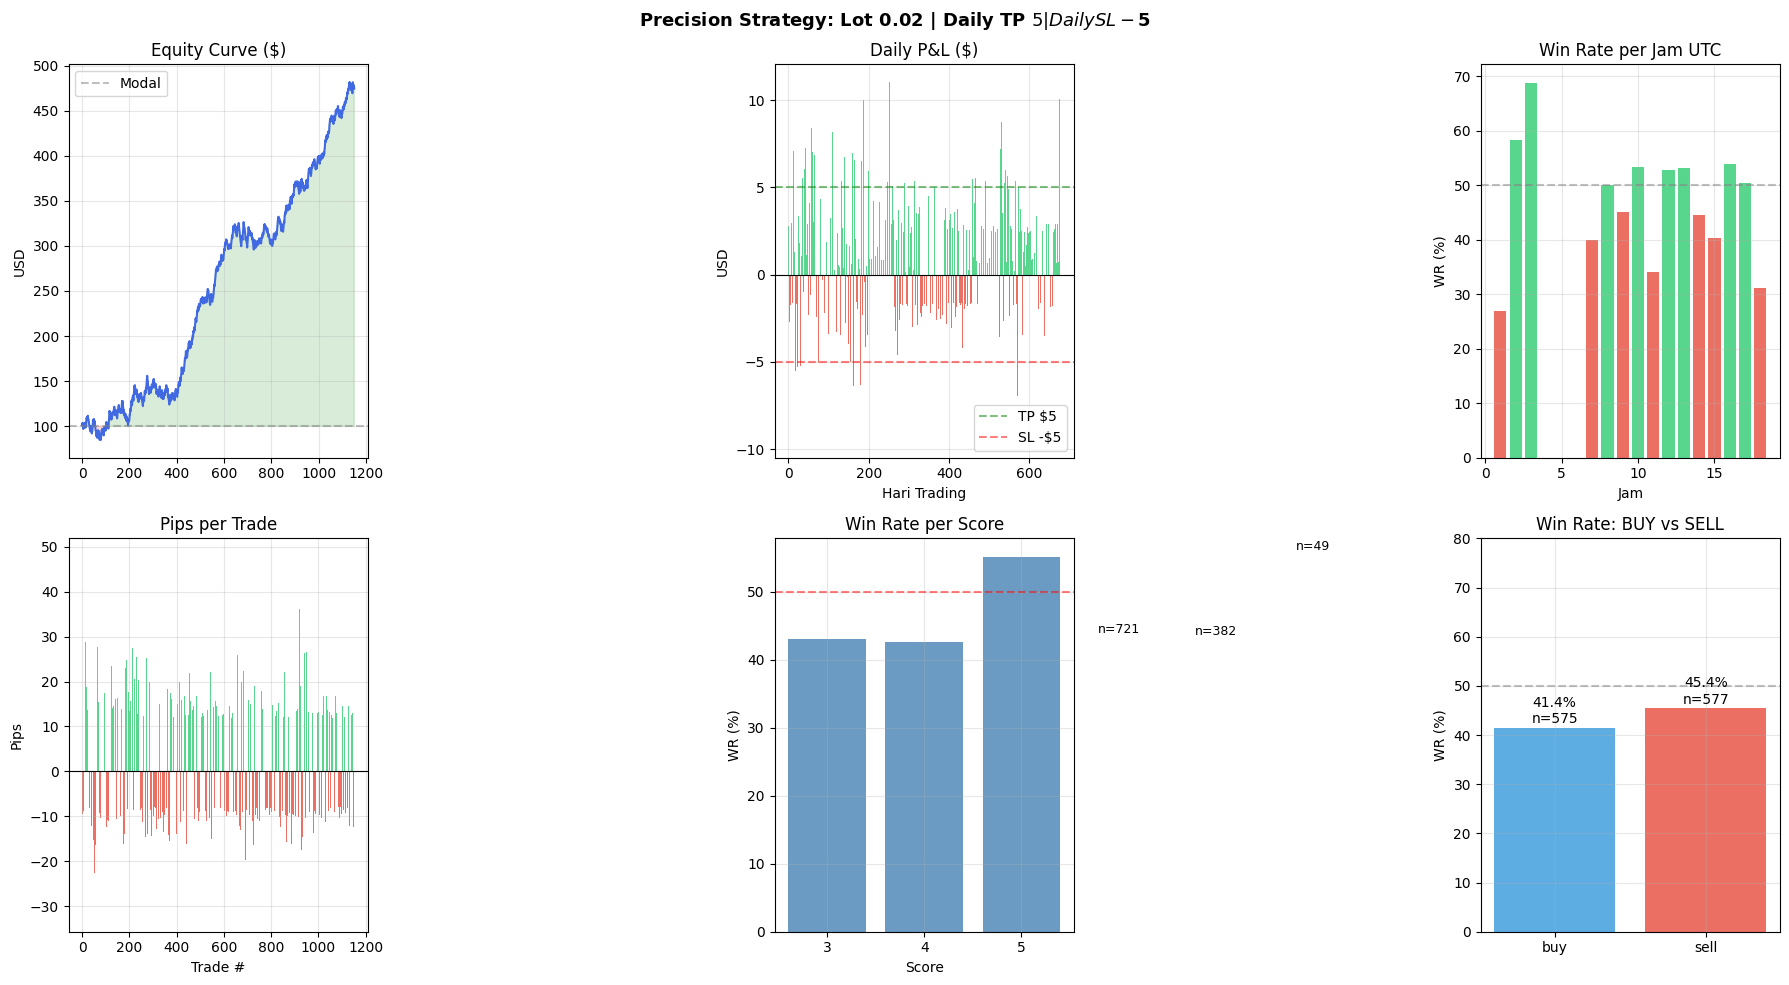

Chart: 10_precision_result.png


In [8]:
# ── Visualisasi ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Precision Strategy: Lot 0.02 | Daily TP $5 | Daily SL -$5', fontsize=13, fontweight='bold')

# 1. Equity curve
ax = axes[0,0]
ax.plot(range(len(trades)), trades['equity'], color='royalblue', lw=1.5)
ax.axhline(100, color='gray', ls='--', alpha=0.5, label='Modal')
ax.fill_between(range(len(trades)), trades['equity'], 100,
                where=trades['equity']>=100, alpha=0.15, color='green')
ax.fill_between(range(len(trades)), trades['equity'], 100,
                where=trades['equity']<100, alpha=0.15, color='red')
ax.set_title('Equity Curve ($)')
ax.set_ylabel('USD'); ax.grid(True, alpha=0.3); ax.legend()

# 2. Daily P&L
ax = axes[0,1]
dpnl = pd.Series(daily_pnl)
dpnl_nonzero = dpnl[dpnl!=0]
colors = ['#2ecc71' if v>0 else '#e74c3c' for v in dpnl_nonzero]
ax.bar(range(len(dpnl_nonzero)), dpnl_nonzero.values, color=colors, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(5,  color='green', ls='--', alpha=0.5, label='TP $5')
ax.axhline(-5, color='red',   ls='--', alpha=0.5, label='SL -$5')
ax.set_title('Daily P&L ($)')
ax.set_xlabel('Hari Trading'); ax.set_ylabel('USD'); ax.legend(); ax.grid(True, alpha=0.3)

# 3. Win rate per jam
ax = axes[0,2]
trades2 = trades.copy()
trades2['hour'] = pd.to_datetime(trades2['datetime']).dt.hour
hr = trades2.groupby('hour').apply(lambda x: pd.Series({
    'wr': (x['outcome']=='win').mean()*100,
    'trades': len(x)
}), include_groups=False).reset_index()
hr = hr[hr['trades']>=3]
colors_hr = ['#2ecc71' if w>=50 else '#e74c3c' for w in hr['wr']]
ax.bar(hr['hour'], hr['wr'], color=colors_hr, alpha=0.8)
ax.axhline(50, color='gray', ls='--', alpha=0.5)
ax.set_title('Win Rate per Jam UTC')
ax.set_xlabel('Jam'); ax.set_ylabel('WR (%)'); ax.grid(True, alpha=0.3)

# 4. Pips per trade
ax = axes[1,0]
colors_t = ['#2ecc71' if p>0 else '#e74c3c' for p in trades['pips']]
ax.bar(range(len(trades)), trades['pips'], color=colors_t, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Pips per Trade')
ax.set_xlabel('Trade #'); ax.set_ylabel('Pips'); ax.grid(True, alpha=0.3)

# 5. Score distribution
ax = axes[1,1]
sc_wr = trades.groupby('score').apply(lambda x: pd.Series({
    'wr': (x['outcome']=='win').mean()*100,
    'n': len(x)
}), include_groups=False).reset_index()
ax.bar(sc_wr['score'].astype(str), sc_wr['wr'], color='steelblue', alpha=0.8)
ax.axhline(50, color='red', ls='--', alpha=0.5)
for _, row in sc_wr.iterrows():
    ax.text(str(row['score']), row['wr']+1, f'n={int(row["n"])}', ha='center', fontsize=9)
ax.set_title('Win Rate per Score')
ax.set_xlabel('Score'); ax.set_ylabel('WR (%)'); ax.grid(True, alpha=0.3)

# 6. Buy vs Sell
ax = axes[1,2]
for idx2, d in enumerate(['buy','sell']):
    t = trades[trades['direction']==d]
    if len(t)==0: continue
    wr = (t['outcome']=='win').mean()*100
    ax.bar(d, wr, color='#3498db' if d=='buy' else '#e74c3c', alpha=0.8)
    ax.text(d, wr+1, f'{wr:.1f}%\nn={len(t)}', ha='center', fontsize=10)
ax.axhline(50, color='gray', ls='--', alpha=0.5)
ax.set_title('Win Rate: BUY vs SELL')
ax.set_ylabel('WR (%)'); ax.set_ylim(0,80); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('10_precision_result.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart: 10_precision_result.png')

In [9]:
# ── Win Rate per Jam detail ────────────────────────────────────────────────
trades2 = trades.copy()
trades2['hour'] = pd.to_datetime(trades2['datetime']).dt.hour
hr = trades2.groupby('hour').apply(lambda x: pd.Series({
    'trades': len(x),
    'wins':   (x['outcome']=='win').sum(),
    'wr':     round((x['outcome']=='win').mean()*100,1),
    'pips':   round(x['pips'].sum(),1),
    'usd':    round(x['usd'].sum(),2)
}), include_groups=False).reset_index()
hr = hr[hr['trades']>=3].sort_values('wr', ascending=False)
print('=== Win Rate per Jam UTC (min 3 trades) ===')
print(hr.to_string(index=False))

print()
print('=== Top 5 Jam Terbaik ===')
top5 = hr.head(5)
for _,row in top5.iterrows():
    print(f'  Jam {int(row["hour"]):02d} UTC: WR={row["wr"]}% | {int(row["trades"])} trades | +${row["usd"]}')

=== Win Rate per Jam UTC (min 3 trades) ===
 hour  trades  wins   wr   pips    usd
    3    16.0  11.0 68.8  123.2  24.65
    2    12.0   7.0 58.3   85.4  17.11
   16   115.0  62.0 53.9  444.6  88.90
   10   120.0  64.0 53.3  411.4  82.28
   13    47.0  25.0 53.2  211.2  42.18
   12    55.0  29.0 52.7  203.4  40.61
   17   119.0  60.0 50.4  447.5  89.53
    8    16.0   8.0 50.0   49.8  10.01
    9    60.0  27.0 45.0   80.9  16.17
   14    74.0  33.0 44.6   74.3  14.93
   15   149.0  60.0 40.3   20.4   3.96
    7    35.0  14.0 40.0   -0.2  -0.03
   11    97.0  33.0 34.0 -126.7 -25.31
   18    77.0  24.0 31.2   20.9   4.22
    1   160.0  43.0 26.9 -173.9 -34.67

=== Top 5 Jam Terbaik ===
  Jam 03 UTC: WR=68.8% | 16 trades | +$24.65
  Jam 02 UTC: WR=58.3% | 12 trades | +$17.11
  Jam 16 UTC: WR=53.9% | 115 trades | +$88.9
  Jam 10 UTC: WR=53.3% | 120 trades | +$82.28
  Jam 13 UTC: WR=53.2% | 47 trades | +$42.18


In [10]:
# ── Simulasi: hanya jam terbaik (WR >= 50%) ────────────────────────────────
hr_good = hr[hr['wr']>=50]['hour'].astype(int).tolist()
print(f'Jam WR >= 50%: {sorted(hr_good)}')

trades_best = trades[trades['datetime'].dt.hour.isin(hr_good)].copy()
trades_best['equity2'] = 100 + trades_best['usd'].cumsum()

if len(trades_best) > 0:
    wins2 = (trades_best['outcome']=='win').sum()
    wr2   = wins2/len(trades_best)*100
    pf2_gp= trades_best.loc[trades_best['pips']>0,'pips'].sum()
    pf2_gl= abs(trades_best.loc[trades_best['pips']<0,'pips'].sum() or 1)
    print()
    print(f'=== Hanya jam WR>=50% ===')
    print(f'  Trades       : {len(trades_best)}')
    print(f'  Win Rate     : {wr2:.1f}%')
    print(f'  Profit Factor: {pf2_gp/pf2_gl:.2f}')
    print(f'  Total USD    : ${trades_best["usd"].sum():+.2f}')
    print(f'  Equity Akhir : ${trades_best["equity2"].iloc[-1]:.2f}')

Jam WR >= 50%: [2, 3, 8, 10, 12, 13, 16, 17]

=== Hanya jam WR>=50% ===
  Trades       : 500
  Win Rate     : 53.2%
  Profit Factor: 1.86
  Total USD    : $+395.27
  Equity Akhir : $495.27


In [11]:
# ── Simpan & Kesimpulan ────────────────────────────────────────────────────
trades.to_csv('10_precision_trades.csv', index=False)
print('Disimpan: 10_precision_trades.csv')
print()
print('='*54)
print('  KESIMPULAN PRECISION STRATEGY')
print('='*54)
print('  Lot     : 0.02  (1 pip = $0.20)')
print('  Daily TP: +$5   stop trading hari itu')
print('  Daily SL: -$5   stop trading hari itu')
print('  RR      : 1:1.5 (SL=1xATR, TP=1.5xATR)')
print()
print('  Signal kuat (score>=3):')
print('  [1+2] Trend H1 (EMA50+200) + S/R Zone H1 = dasar')
print('  [3]   MACD histogram arah searah')
print('  [4]   EMA9>EMA21 M15 searah')
print('  [5]   Candle pattern (pin bar/engulfing)')
print()
print('  Trading hanya di jam London + NY open')
print('  (jam Asia pagi opsional jika WR bagus)')
print('='*54)

Disimpan: 10_precision_trades.csv

  KESIMPULAN PRECISION STRATEGY
  Lot     : 0.02  (1 pip = $0.20)
  Daily TP: +$5   stop trading hari itu
  Daily SL: -$5   stop trading hari itu
  RR      : 1:1.5 (SL=1xATR, TP=1.5xATR)

  Signal kuat (score>=3):
  [1+2] Trend H1 (EMA50+200) + S/R Zone H1 = dasar
  [3]   MACD histogram arah searah
  [4]   EMA9>EMA21 M15 searah
  [5]   Candle pattern (pin bar/engulfing)

  Trading hanya di jam London + NY open
  (jam Asia pagi opsional jika WR bagus)
